# VOIS AICTE Major Project
# Seasonal Agriculture Performance Analysis

**Student Name:** C PUSHPALATHA  
**AICTE ID:** STU696132c929d891767977673  
**College:** Justice Basheer Ahmed Sayeed College for Women  
**GitHub:** https://github.com/cpushpalatha9

## Project Objective
Analyze agricultural data across different seasons and identify meaningful patterns, trends,
relationships, variations, and evidence-based recommendations.

This notebook follows the VOIS major-project requirements:
- Explore and understand the dataset
- Clean and prepare the data
- Compare agricultural performance across seasons
- Identify seasonal patterns and trends
- Investigate environmental/resource relationships
- Compare relevant groups
- Identify unusual patterns
- Apply statistical and visualization techniques
- Interpret findings
- Produce conclusions and recommendations

**Reference used for workflow design:** the public VOIS-Project sample repository supplied by the student.
The code below is an original, consolidated notebook for this submission rather than a copy of the
sample student's notebook.

## 1. Business / Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions,
farming practices, resource availability and market conditions. As a result, agricultural
performance may differ from one season to another.

The purpose of this project is to analyze the agricultural dataset and investigate seasonal
differences in agricultural performance by identifying meaningful patterns, trends,
relationships and variations within the available data.

## 2. Analytical Questions

1. How does agricultural performance vary across seasons?
2. What major seasonal patterns can be observed?
3. Which crop and farm characteristics change between seasons?
4. How does resource usage vary across seasons?
5. Are environmental conditions related to yield and production?
6. How do revenue, cost and profit vary across seasons?
7. Which crops or regions show stronger performance?
8. Are there unusual or extreme observations?
9. Which seasonal combinations appear more water-efficient?
10. What evidence-based recommendations can be made for seasonal planning?

In [1]:
# Optional: run this once if any package is missing.
# %pip install pandas numpy matplotlib seaborn scipy openpyxl

In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

sns.set_theme(style="whitegrid")
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 3. Upload and Load the Dataset

The notebook provides a **Choose File** option so the student can upload the CSV directly from
their local PC. No GitHub dataset URL is required.

**Run the upload cell first, choose your CSV file, and then run the next cells in order.**

In [3]:
# ============================================================
# UPLOAD YOUR CSV FILE
# ============================================================
# Run this cell first. A "Choose File" button will appear.
# Select your agricultural CSV file from your PC.
#
# Works in Jupyter Notebook / JupyterLab and Google Colab.
# ============================================================

import os
import pandas as pd
from IPython.display import display, clear_output
import ipywidgets as widgets

try:
    from google.colab import files as colab_files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

uploaded_file_name = None

if IN_COLAB:
    print("Google Colab detected.")
    print("Click 'Choose Files' below and select your CSV file.")
    uploaded = colab_files.upload()

    if not uploaded:
        raise ValueError("No file was selected. Please run this cell again and choose your CSV file.")

    uploaded_file_name = next(iter(uploaded))
    print(f"\nUploaded successfully: {uploaded_file_name}")

else:
    print("Jupyter Notebook/JupyterLab detected.")
    print("Click 'Choose File' and select your CSV file.")

    upload_widget = widgets.FileUpload(
        accept=".csv",
        multiple=False,
        description="Choose File",
        button_style="primary"
    )

    display(upload_widget)

    def handle_upload(change):
        global uploaded_file_name
        if not upload_widget.value:
            return

        # Compatible with current ipywidgets versions.
        value = upload_widget.value
        if isinstance(value, dict):
            uploaded_file_name = next(iter(value))
            content = value[uploaded_file_name]["content"]
        else:
            item = value[0]
            uploaded_file_name = item["name"]
            content = item["content"]

        with open(uploaded_file_name, "wb") as f:
            f.write(content)

        print(f"\nUploaded successfully: {uploaded_file_name}")

    upload_widget.observe(handle_upload, names="value")

print("\nAfter the upload completes, run the next cells in order.")

Google Colab detected.
Click 'Choose Files' below and select your CSV file.


Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset.csv

Uploaded successfully: seasonal_agriculture_performance_dataset.csv

After the upload completes, run the next cells in order.


In [4]:
# ============================================================
# LOAD THE UPLOADED CSV
# ============================================================

if uploaded_file_name is None:
    raise ValueError(
        "Please run the previous UPLOAD YOUR CSV FILE cell first "
        "and select your CSV file."
    )

df_raw = pd.read_csv(uploaded_file_name)

print("Dataset loaded successfully!")
print("File:", uploaded_file_name)
print("Rows:", df_raw.shape[0])
print("Columns:", df_raw.shape[1])

display(df_raw.head())

Dataset loaded successfully!
File: seasonal_agriculture_performance_dataset.csv
Rows: 4000
Columns: 28


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.530,486.400,24.300,69.100,5.800,7.140,32.800,75.800,61.300,91.000,Drip,242.700,4.330,0.760,2.460,1.300,23700,42662,30810,-11852,237,5.485,55.300
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.530,855.400,25.700,78.400,5.100,5.200,32.000,82.100,35.400,121.800,Flood,271.400,6.860,0.940,0.300,1.960,20613,492351,40401,-451950,4953,0.396,49.900
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.860,455.600,23.900,56.400,10.300,5.820,8.100,118.500,51.500,117.900,Drip,162.600,6.080,0.980,0.520,2.530,75283,315210,190466,-124744,1275,1.984,33.700
3,SF10004,Telangana,Indore,Rice,Kharif,4.500,753.200,29.700,65.200,6.300,5.980,23.700,138.600,55.600,115.500,Rainfed,182.200,6.390,0.740,1.840,8.280,24244,296444,200740,-95704,3834,2.160,50.600
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.210,101.600,34.100,55.200,6.500,6.900,29.300,124.100,69.000,121.400,Flood,244.900,7.610,0.900,2.210,9.300,20818,337959,193607,-144352,3287,2.829,32.300


In [5]:
# Preserve the original data and work on a separate copy.
df = df_raw.copy()

print("Dataset shape:", df.shape)
print("\nColumn names:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:02d}. {col}")

Dataset shape: (4000, 28)

Column names:
01. Farm_ID
02. State
03. District
04. Crop
05. Season
06. Farm_Area_Hectares
07. Rainfall_mm
08. Avg_Temperature_C
09. Humidity_pct
10. Sunlight_Hours_Day
11. Soil_pH
12. Soil_Moisture_pct
13. Nitrogen_kg_ha
14. Phosphorus_kg_ha
15. Potassium_kg_ha
16. Irrigation_Method
17. Fertilizer_kg_ha
18. Pesticide_Litre_ha
19. Seed_Quality_Score
20. Yield_Tonnes_Ha
21. Production_Tonnes
22. Market_Price_INR_Tonne
23. Total_Cost_INR
24. Revenue_INR
25. Profit_INR
26. Water_Used_m3
27. Water_Efficiency_t_per_1000m3
28. Disease_Pest_Risk_pct


## 4. Dataset Structure and Data Types

In [6]:
print("DATA TYPES")
display(pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Non_Null_Count": df.notna().sum().values,
    "Missing_Count": df.isna().sum().values
}))

DATA TYPES


,Column,Data_Type,Non_Null_Count,Missing_Count
0,Farm_ID,object,4000,0
1,State,object,4000,0
2,District,object,4000,0
3,Crop,object,4000,0
4,Season,object,4000,0
5,Farm_Area_Hectares,float64,4000,0
6,Rainfall_mm,float64,3952,48
7,Avg_Temperature_C,float64,4000,0
8,Humidity_pct,float64,4000,0
9,Sunlight_Hours_Day,float64,4000,0


In [7]:
print("NUMERICAL SUMMARY")
display(df.describe(include=[np.number]).T)

print("\nCATEGORICAL SUMMARY")
cat_cols = df.select_dtypes(include=["object", "category"]).columns
if len(cat_cols):
    display(df[cat_cols].describe().T)

NUMERICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,"4,000.000",7.888,4.224,0.500,4.260,7.895,11.650,15.000
Rainfall_mm,"3,952.000",601.153,288.925,80.000,370.200,582.000,834.950,"1,395.200"
Avg_Temperature_C,"4,000.000",26.819,3.818,16.200,23.900,26.900,29.600,39.700
Humidity_pct,"4,000.000",63.211,11.961,25.000,54.775,63.000,71.900,95.000
Sunlight_Hours_Day,"4,000.000",7.323,1.121,3.500,6.600,7.300,8.100,11.000
Soil_pH,"4,000.000",6.701,0.641,5.200,6.260,6.690,7.140,8.400
Soil_Moisture_pct,"3,960.000",26.508,6.712,8.000,21.700,26.400,31.300,47.000
Nitrogen_kg_ha,"4,000.000",120.251,31.216,40.000,98.500,120.100,141.225,220.000
Phosphorus_kg_ha,"4,000.000",57.782,17.015,15.000,46.200,57.500,69.400,120.000
Potassium_kg_ha,"4,000.000",104.760,27.743,30.000,86.200,105.100,123.600,200.000



CATEGORICAL SUMMARY


,count,unique,top,freq
Farm_ID,4000,4000,SF13984,1
State,4000,8,Andhra Pradesh,529
District,4000,10,Ludhiana,427
Crop,4000,8,Rice,690
Season,4000,3,Kharif,1779
Irrigation_Method,4000,4,Flood,1310


## 5. Data Quality Checks

The following checks cover missing values, duplicates, constant columns and basic validity.

In [8]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

quality = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percent": missing_pct
})
display(quality[quality["Missing_Count"] > 0])

print("Duplicate rows:", df.duplicated().sum())

constant_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
print("Constant columns:", constant_cols if constant_cols else "None")

,Missing_Count,Missing_Percent
Rainfall_mm,48,1.200
Soil_Moisture_pct,40,1.000
Yield_Tonnes_Ha,32,0.800


Duplicate rows: 0
Constant columns: None


### Cleaning Strategy

- Standardize column names.
- Remove exact duplicate rows.
- Convert numeric-looking columns to numeric where appropriate.
- Fill numeric missing values with the median where necessary.
- Fill categorical missing values with the mode where necessary.
- Do not silently remove legitimate high/low agricultural observations.
- Use IQR-based outlier analysis for investigation rather than automatically deleting observations.

In [9]:
# Standardize column names while keeping the dataset readable.
df.columns = (
    df.columns
      .str.strip()
      .str.replace(r"[^0-9A-Za-z]+", "_", regex=True)
      .str.strip("_")
)

# Remove exact duplicates.
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print("Duplicate rows removed:", before - len(df))

# Convert object columns that are mostly numeric into numeric values.
for col in df.columns:
    if df[col].dtype == "object":
        converted = pd.to_numeric(df[col], errors="coerce")
        if converted.notna().mean() >= 0.90:
            df[col] = converted

# Fill missing values.
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include=["object", "category"]).columns

for col in num_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    if df[col].isna().any():
        mode = df[col].mode()
        df[col] = df[col].fillna(mode.iloc[0] if not mode.empty else "Unknown")

print("Remaining missing values:", int(df.isna().sum().sum()))
print("Cleaned shape:", df.shape)

Duplicate rows removed: 0
Remaining missing values: 0
Cleaned shape: (4000, 28)


In [10]:
# Inspect the key categorical dimensions.
for col in ["State", "District", "Crop", "Season", "Irrigation_Method"]:
    if col in df.columns:
        print(f"\n{col}: {df[col].nunique()} unique values")
        display(df[col].value_counts().to_frame("Count").head(15))


State: 8 unique values


,Count
State,
Andhra Pradesh,529
Telangana,516
Maharashtra,512
Madhya Pradesh,497
Karnataka,489
Gujarat,488
Tamil Nadu,485
Punjab,484



District: 10 unique values


,Count
District,
Ludhiana,427
Warangal,422
Nalgonda,415
Erode,403
Rajkot,401
Krishna,393
Indore,392
Guntur,390
Raichur,386



Crop: 8 unique values


,Count
Crop,
Rice,690
Wheat,614
Maize,551
Cotton,508
Pulses,496
Groundnut,424
Chilli,412
Sugarcane,305



Season: 3 unique values


,Count
Season,
Kharif,1779
Rabi,1627
Zaid,594



Irrigation_Method: 4 unique values


,Count
Irrigation_Method,
Flood,1310
Rainfed,1041
Drip,915
Sprinkler,734


## 6. Derived Metrics / Feature Preparation

The sample project contains operational and economic variables. We create only metrics that can
be calculated from available columns, and we avoid inventing values.

In [11]:
# Safe derived metrics where the source columns exist.
if {"Production_Tonnes", "Farm_Area_Hectares"}.issubset(df.columns):
    df["Calculated_Yield_Tonnes_Ha"] = np.where(
        df["Farm_Area_Hectares"] > 0,
        df["Production_Tonnes"] / df["Farm_Area_Hectares"],
        np.nan
    )

if {"Revenue_INR", "Total_Cost_INR"}.issubset(df.columns):
    df["Calculated_Profit_INR"] = df["Revenue_INR"] - df["Total_Cost_INR"]

if {"Revenue_INR", "Total_Cost_INR"}.issubset(df.columns):
    df["Calculated_Profit_Margin_pct"] = np.where(
        df["Revenue_INR"] != 0,
        (df["Revenue_INR"] - df["Total_Cost_INR"]) / df["Revenue_INR"] * 100,
        np.nan
    )

if {"Production_Tonnes", "Water_Used_m3"}.issubset(df.columns):
    df["Calculated_Water_Productivity"] = np.where(
        df["Water_Used_m3"] > 0,
        df["Production_Tonnes"] / df["Water_Used_m3"],
        np.nan
    )

display(df.head())

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Calculated_Yield_Tonnes_Ha,Calculated_Profit_INR,Calculated_Profit_Margin_pct,Calculated_Water_Productivity
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.530,486.400,24.300,69.100,5.800,7.140,32.800,75.800,61.300,91.000,Drip,242.700,4.330,0.760,2.460,1.300,23700,42662,30810,-11852,237,5.485,55.300,2.453,-11852,-38.468,0.005
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.530,855.400,25.700,78.400,5.100,5.200,32.000,82.100,35.400,121.800,Flood,271.400,6.860,0.940,0.300,1.960,20613,492351,40401,-451950,4953,0.396,49.900,0.300,-451950,"-1,118.660",0.000
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.860,455.600,23.900,56.400,10.300,5.820,8.100,118.500,51.500,117.900,Drip,162.600,6.080,0.980,0.520,2.530,75283,315210,190466,-124744,1275,1.984,33.700,0.521,-124744,-65.494,0.002
3,SF10004,Telangana,Indore,Rice,Kharif,4.500,753.200,29.700,65.200,6.300,5.980,23.700,138.600,55.600,115.500,Rainfed,182.200,6.390,0.740,1.840,8.280,24244,296444,200740,-95704,3834,2.160,50.600,1.840,-95704,-47.676,0.002
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.210,101.600,34.100,55.200,6.500,6.900,29.300,124.100,69.000,121.400,Flood,244.900,7.610,0.900,2.210,9.300,20818,337959,193607,-144352,3287,2.829,32.300,2.209,-144352,-74.559,0.003


## 7. KPI Summary

These KPIs provide a compact view of the project dataset.

In [12]:
def safe_sum(col):
    return df[col].sum() if col in df.columns else np.nan

def safe_mean(col):
    return df[col].mean() if col in df.columns else np.nan

kpis = {
    "Total Records": len(df),
    "States": df["State"].nunique() if "State" in df.columns else np.nan,
    "Districts": df["District"].nunique() if "District" in df.columns else np.nan,
    "Crops": df["Crop"].nunique() if "Crop" in df.columns else np.nan,
    "Seasons": df["Season"].nunique() if "Season" in df.columns else np.nan,
    "Total Production (t)": safe_sum("Production_Tonnes"),
    "Average Yield (t/ha)": safe_mean("Yield_Tonnes_Ha"),
    "Total Revenue (INR)": safe_sum("Revenue_INR"),
    "Total Profit (INR)": safe_sum("Profit_INR"),
    "Average Water Use (m3)": safe_mean("Water_Used_m3")
}

kpi_df = pd.DataFrame(kpis.items(), columns=["KPI", "Value"])
display(kpi_df)

,KPI,Value
0,Total Records,"4,000.000"
1,States,8.000
2,Districts,10.000
3,Crops,8.000
4,Seasons,3.000
5,Total Production (t),"172,984.840"
6,Average Yield (t/ha),5.242
7,Total Revenue (INR),"2,551,440,192.000"
8,Total Profit (INR),"446,225,860.000"
9,Average Water Use (m3),"6,045.570"


## 8. Seasonal Distribution

The project specifically requires investigation of seasonal differences.

,Records
Season,
Kharif,1779
Rabi,1627
Zaid,594


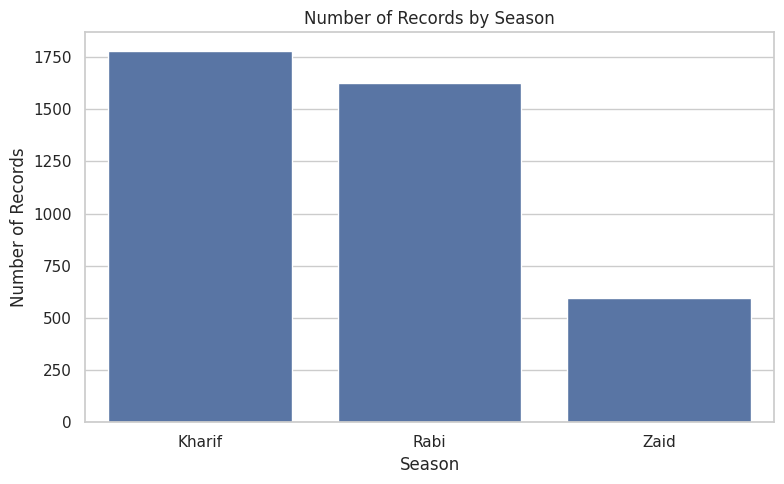

In [13]:
if "Season" in df.columns:
    season_counts = df["Season"].value_counts().sort_index()
    display(season_counts.to_frame("Records"))

    plt.figure(figsize=(8, 5))
    sns.barplot(x=season_counts.index, y=season_counts.values)
    plt.title("Number of Records by Season")
    plt.xlabel("Season")
    plt.ylabel("Number of Records")
    plt.tight_layout()
    plt.show()

## 9. Seasonal Performance Comparison

We compare production, yield, revenue, profit, cost and water use where the columns are available.

In [14]:
season_metrics = [
    c for c in [
        "Farm_Area_Hectares",
        "Yield_Tonnes_Ha",
        "Production_Tonnes",
        "Revenue_INR",
        "Total_Cost_INR",
        "Profit_INR",
        "Water_Used_m3",
        "Disease_Pest_Risk_pct",
        "Water_Efficiency_t_per_1000m3"
    ] if c in df.columns
]

season_summary = df.groupby("Season")[season_metrics].agg(["mean", "sum"])
display(season_summary)

Farm_Area_Hectares            Yield_Tonnes_Ha             \
                     mean        sum            mean        sum   
Season                                                            
Kharif              7.945 14,134.020           5.629 10,013.300   
Rabi                7.752 12,612.840           5.039  8,199.160   
Zaid                8.091  4,806.200           4.641  2,756.940   

       Production_Tonnes            Revenue_INR             Total_Cost_INR  \
                    mean        sum        mean         sum           mean   
Season                                                                       
Kharif            46.311 82,387.610 710,719.056  1264369200    531,804.408   
Rabi              41.487 67,498.880 601,526.049   978682881    513,836.578   
Zaid              38.886 23,098.350 519,171.904   308388111    543,976.729   

                   Profit_INR            Water_Used_m3            \
              sum        mean        sum          mean       sum   
Season                                                             
Kharif  946080042 178,914.648  318289158     6,102.201  10855816   
Rabi    836012113  87,689.470  142670768     5,846.987   9513048   
Zaid    323122177 -24,804.825  -14734066     6,419.894   3813417   

       Disease_Pest_Risk_pct            Water_Efficiency_t_per_1000m3  \
                        mean        sum                          mean   
Season                                                                  
Kharif                54.468 96,898.400                         5.892   
Rabi                  40.482 65,864.400                         5.186   
Zaid                  38.217 22,700.700                         4.413   

                   
              sum  
Season             
Kharif 10,481.572  
Rabi    8,437.821  
Zaid    2,621.464

,Average Yield
Season,
Kharif,5.629
Rabi,5.039
Zaid,4.641


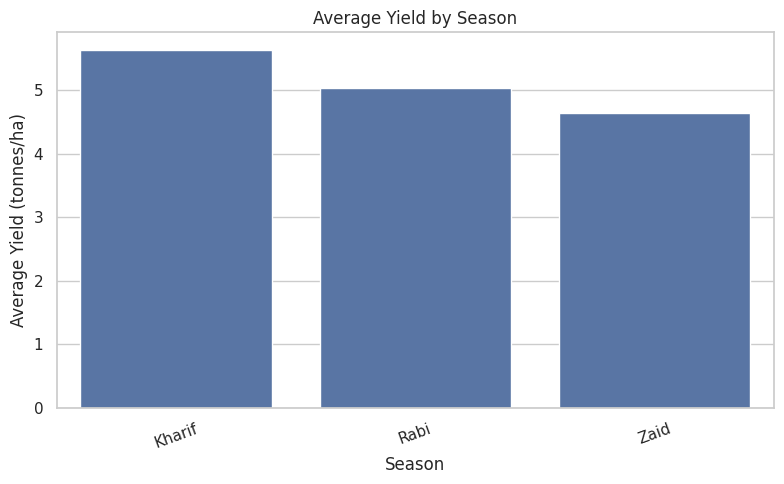

In [15]:
# Mean yield by season
if {"Season", "Yield_Tonnes_Ha"}.issubset(df.columns):
    yield_season = df.groupby("Season")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)
    display(yield_season.to_frame("Average Yield"))

    plt.figure(figsize=(8, 5))
    sns.barplot(x=yield_season.index, y=yield_season.values)
    plt.title("Average Yield by Season")
    plt.xlabel("Season")
    plt.ylabel("Average Yield (tonnes/ha)")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

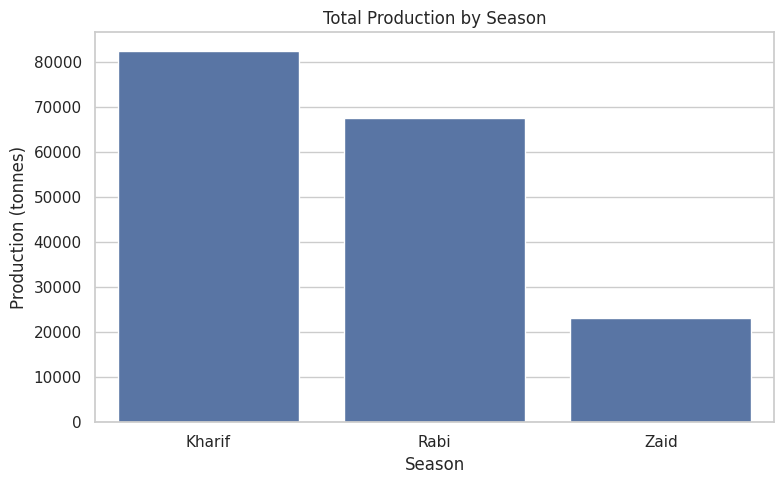

In [16]:
# Total production by season
if {"Season", "Production_Tonnes"}.issubset(df.columns):
    prod_season = df.groupby("Season")["Production_Tonnes"].sum().sort_values(ascending=False)

    plt.figure(figsize=(8, 5))
    sns.barplot(x=prod_season.index, y=prod_season.values)
    plt.title("Total Production by Season")
    plt.xlabel("Season")
    plt.ylabel("Production (tonnes)")
    plt.tight_layout()
    plt.show()

## 10. Seasonal Environmental Conditions

The VOIS brief asks for relationships between seasonal conditions and agricultural outcomes.

In [17]:
environment_cols = [
    c for c in [
        "Rainfall_mm",
        "Avg_Temperature_C",
        "Humidity_pct",
        "Sunlight_Hours_Day",
        "Soil_pH",
        "Soil_Moisture_pct"
    ] if c in df.columns
]

if environment_cols:
    seasonal_environment = df.groupby("Season")[environment_cols].mean().round(3)
    display(seasonal_environment)

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct
Season,,,,,,
Kharif,849.200,28.454,71.813,6.793,6.728,31.150
Rabi,437.615,23.489,57.893,7.590,6.674,24.069
Zaid,304.655,31.042,52.012,8.179,6.695,19.280


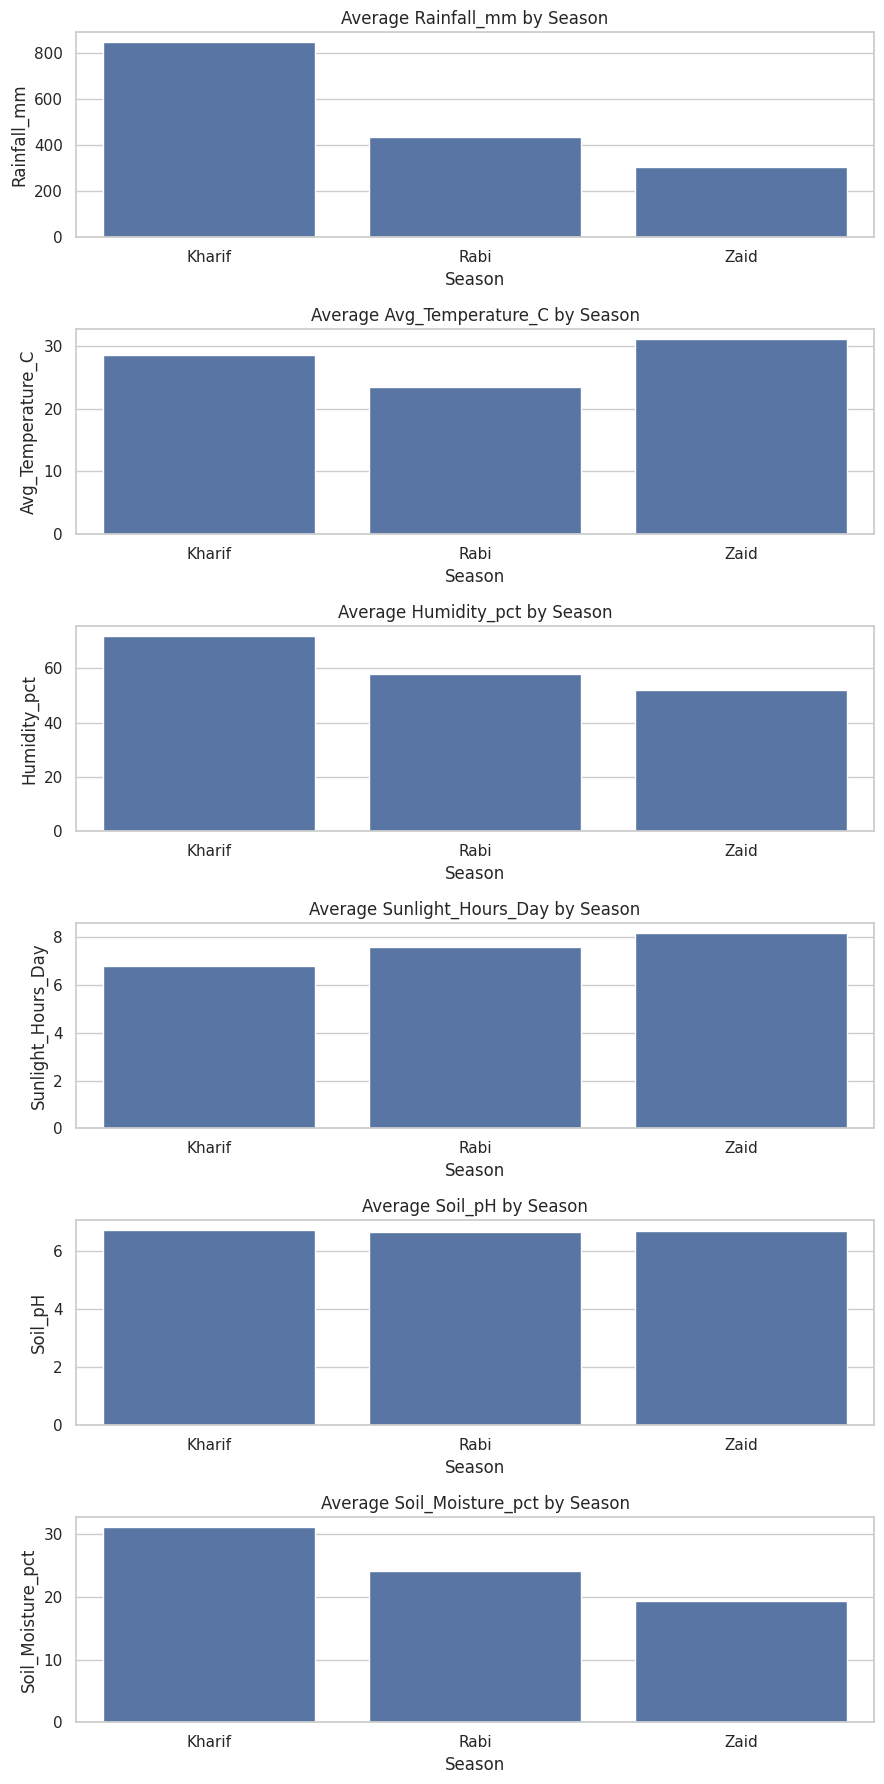

In [18]:
if environment_cols:
    fig, axes = plt.subplots(
        nrows=len(environment_cols), ncols=1,
        figsize=(9, max(4, 3 * len(environment_cols)))
    )
    if len(environment_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, environment_cols):
        sns.barplot(data=df, x="Season", y=col, estimator="mean", errorbar=None, ax=ax)
        ax.set_title(f"Average {col} by Season")
        ax.set_xlabel("Season")
        ax.set_ylabel(col)

    plt.tight_layout()
    plt.show()

## 11. Crop-wise Seasonal Analysis

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.731,1.465,1.195
Cotton,1.375,1.198,0.960
Groundnut,1.485,1.233,1.038
Maize,2.966,2.604,2.291
Pulses,1.036,0.876,0.670
Rice,2.698,2.323,1.900
Sugarcane,53.459,43.286,38.424
Wheat,2.254,2.057,1.749


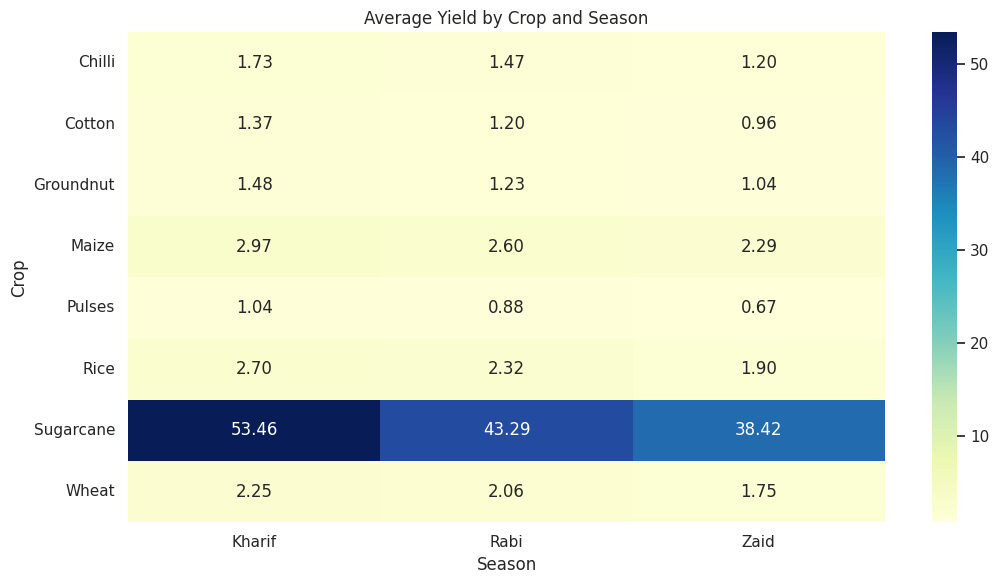

In [19]:
if {"Crop", "Season", "Yield_Tonnes_Ha"}.issubset(df.columns):
    crop_season_yield = (
        df.groupby(["Crop", "Season"])["Yield_Tonnes_Ha"]
          .mean()
          .reset_index()
    )

    pivot = crop_season_yield.pivot(index="Crop", columns="Season", values="Yield_Tonnes_Ha")
    display(pivot.round(3))

    plt.figure(figsize=(11, 6))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu")
    plt.title("Average Yield by Crop and Season")
    plt.xlabel("Season")
    plt.ylabel("Crop")
    plt.tight_layout()
    plt.show()

,Total Production
Crop,
Sugarcane,"119,685.970"
Rice,"13,309.150"
Maize,"12,001.400"
Wheat,"10,348.300"
Chilli,"5,101.750"
Cotton,"4,773.100"
Groundnut,"4,094.070"
Pulses,"3,671.100"


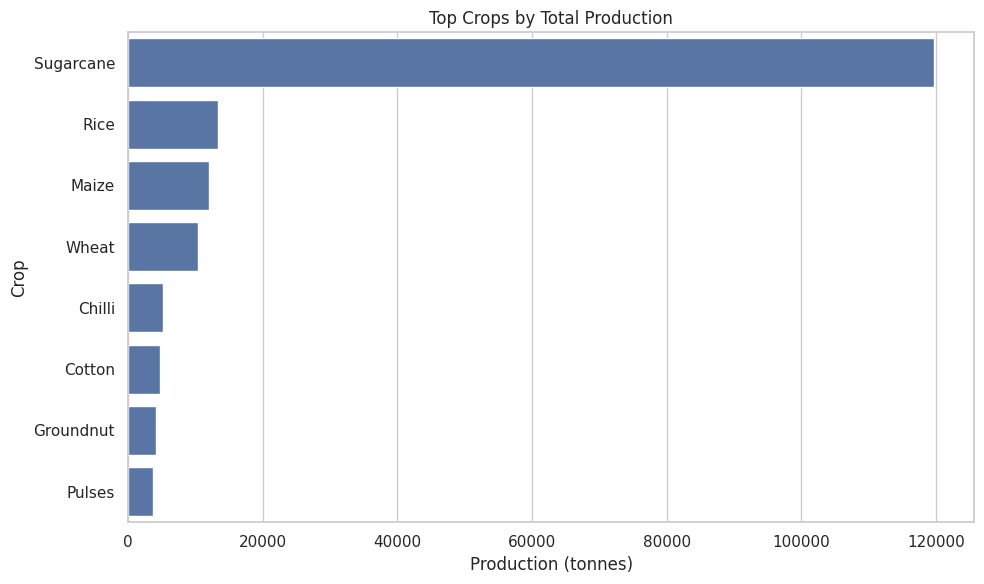

In [20]:
if {"Crop", "Production_Tonnes"}.issubset(df.columns):
    top_crops = (
        df.groupby("Crop")["Production_Tonnes"]
          .sum()
          .sort_values(ascending=False)
          .head(10)
    )

    display(top_crops.to_frame("Total Production"))

    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_crops.values, y=top_crops.index)
    plt.title("Top Crops by Total Production")
    plt.xlabel("Production (tonnes)")
    plt.ylabel("Crop")
    plt.tight_layout()
    plt.show()

## 12. Regional Analysis

Regional comparisons help identify whether seasonal performance is consistent across locations.

,State,Season,Yield_Tonnes_Ha
0,Andhra Pradesh,Kharif,5.677
1,Andhra Pradesh,Rabi,3.471
2,Andhra Pradesh,Zaid,4.448
3,Gujarat,Kharif,6.338
4,Gujarat,Rabi,5.442
5,Gujarat,Zaid,4.067
6,Karnataka,Kharif,6.455
7,Karnataka,Rabi,4.568
8,Karnataka,Zaid,6.623
9,Madhya Pradesh,Kharif,5.985


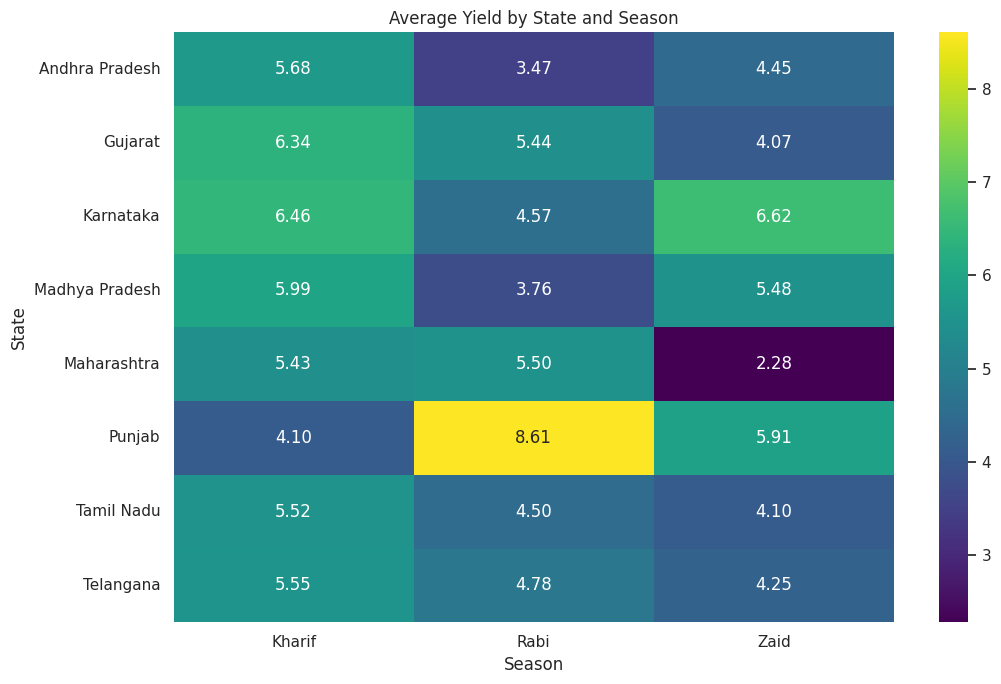

In [21]:
if {"State", "Season", "Yield_Tonnes_Ha"}.issubset(df.columns):
    state_season = (
        df.groupby(["State", "Season"])["Yield_Tonnes_Ha"]
          .mean()
          .reset_index()
    )
    display(state_season.head(20))

    pivot_state = state_season.pivot(index="State", columns="Season", values="Yield_Tonnes_Ha")

    plt.figure(figsize=(11, 7))
    sns.heatmap(pivot_state, annot=True, fmt=".2f", cmap="viridis")
    plt.title("Average Yield by State and Season")
    plt.xlabel("Season")
    plt.ylabel("State")
    plt.tight_layout()
    plt.show()

## 13. Irrigation and Resource Usage

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.770,33.160,26.030,18.040
Rabi,22.740,32.330,26.920,18.010
Zaid,23.570,32.660,23.570,20.200


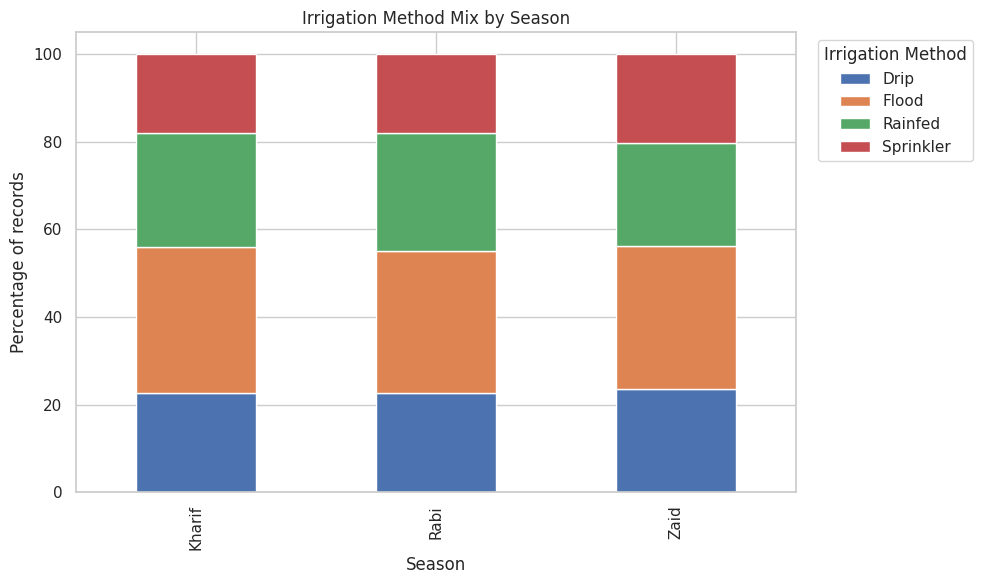

In [22]:
if {"Season", "Irrigation_Method"}.issubset(df.columns):
    irrigation_mix = pd.crosstab(df["Season"], df["Irrigation_Method"], normalize="index") * 100
    display(irrigation_mix.round(2))

    irrigation_mix.plot(kind="bar", stacked=True, figsize=(10, 6))
    plt.title("Irrigation Method Mix by Season")
    plt.xlabel("Season")
    plt.ylabel("Percentage of records")
    plt.legend(title="Irrigation Method", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

In [23]:
resource_cols = [
    c for c in [
        "Farm_Area_Hectares",
        "Fertilizer_kg_ha",
        "Pesticide_Litre_ha",
        "Water_Used_m3",
        "Water_Efficiency_t_per_1000m3"
    ] if c in df.columns
]

if resource_cols:
    resource_by_season = df.groupby("Season")[resource_cols].mean().round(3)
    display(resource_by_season)

,Farm_Area_Hectares,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,,
Kharif,7.945,187.078,5.080,"6,102.201",5.892
Rabi,7.752,185.407,5.025,"5,846.987",5.186
Zaid,8.091,184.638,5.171,"6,419.894",4.413


## 14. Economic Performance by Season

In [24]:
economic_cols = [
    c for c in [
        "Market_Price_INR_Tonne",
        "Total_Cost_INR",
        "Revenue_INR",
        "Profit_INR"
    ] if c in df.columns
]

if economic_cols:
    economic_summary = df.groupby("Season")[economic_cols].mean().round(2)
    display(economic_summary)

,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR
Season,,,,
Kharif,"44,850.910","531,804.410","710,719.060","178,914.650"
Rabi,"44,747.970","513,836.580","601,526.050","87,689.470"
Zaid,"44,212.030","543,976.730","519,171.900","-24,804.820"


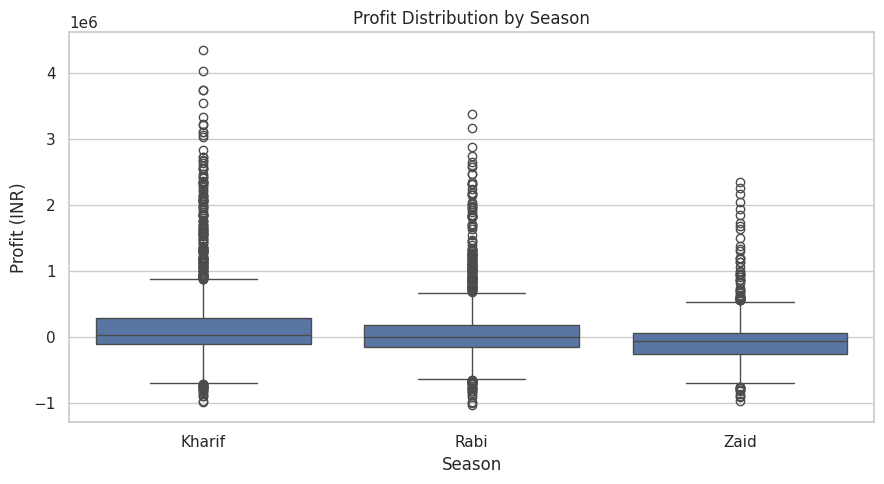

In [25]:
if {"Season", "Profit_INR"}.issubset(df.columns):
    plt.figure(figsize=(9, 5))
    sns.boxplot(data=df, x="Season", y="Profit_INR")
    plt.title("Profit Distribution by Season")
    plt.xlabel("Season")
    plt.ylabel("Profit (INR)")
    plt.tight_layout()
    plt.show()

## 15. Correlation Analysis

Correlation is used to identify linear associations. It does not by itself prove causation.

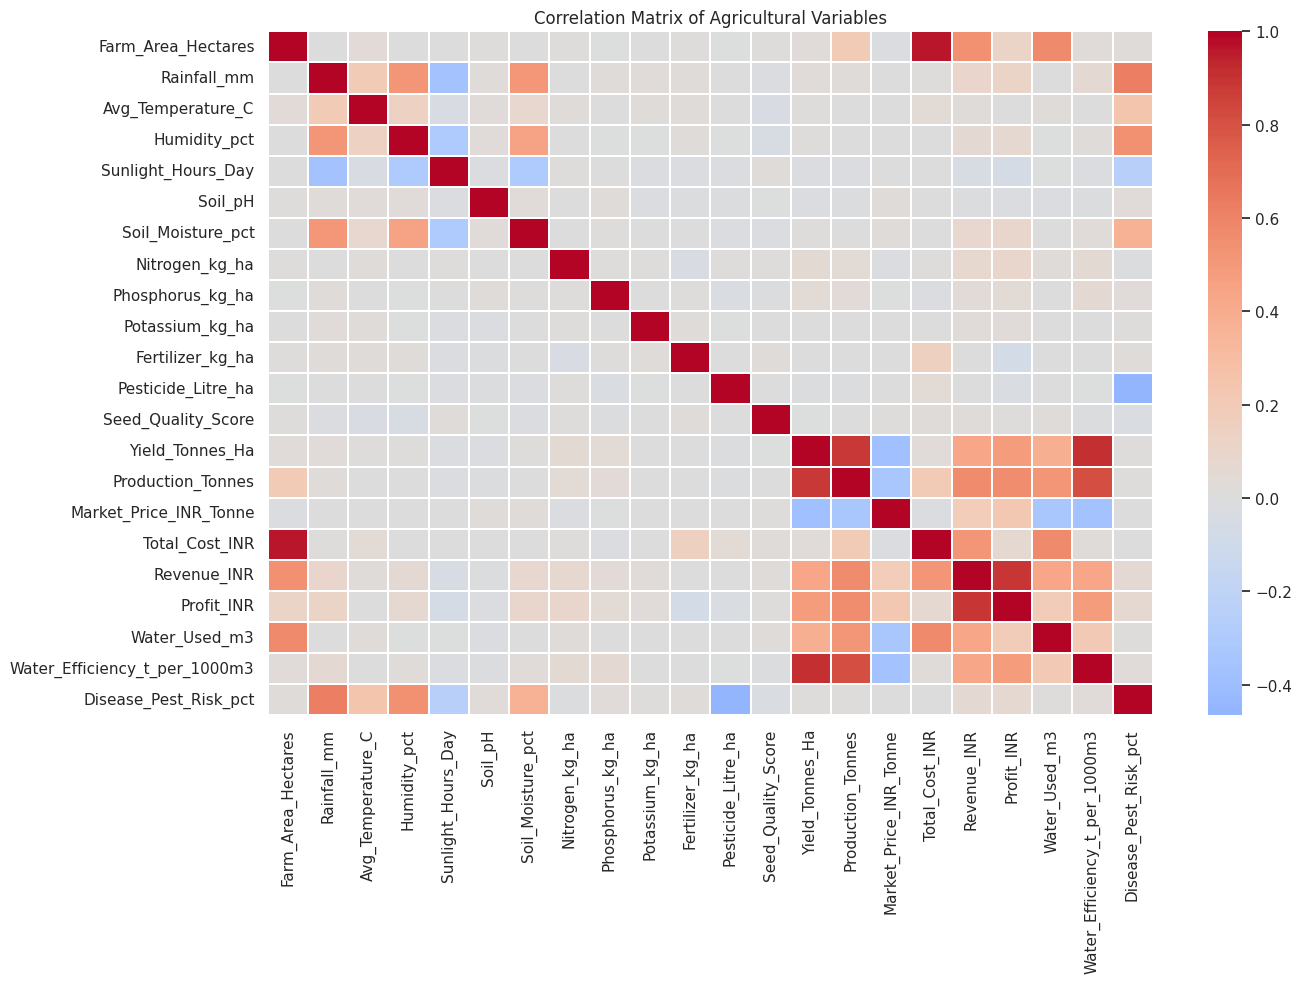

In [26]:
corr_cols = ['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']
corr_cols = [c for c in corr_cols if c in df.columns]

if len(corr_cols) >= 2:
    corr = df[corr_cols].corr()

    plt.figure(figsize=(14, 10))
    sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.3)
    plt.title("Correlation Matrix of Agricultural Variables")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric variables for a correlation matrix.")

In [27]:
if "Yield_Tonnes_Ha" in df.columns and "corr" in globals():
    yield_corr = corr["Yield_Tonnes_Ha"].drop("Yield_Tonnes_Ha").sort_values()
    print("Variables most negatively associated with yield:")
    display(yield_corr.head(5).to_frame("Correlation"))
    print("Variables most positively associated with yield:")
    display(yield_corr.tail(5).sort_values(ascending=False).to_frame("Correlation"))

Variables most negatively associated with yield:


,Correlation
Market_Price_INR_Tonne,-0.383
Soil_pH,-0.021
Sunlight_Hours_Day,-0.015
Pesticide_Litre_ha,-0.008
Seed_Quality_Score,-0.007


Variables most positively associated with yield:


,Correlation
Water_Efficiency_t_per_1000m3,0.913
Production_Tonnes,0.883
Profit_INR,0.488
Revenue_INR,0.432
Water_Used_m3,0.386


## 16. Relationship Plots

The following plots examine important environmental/resource relationships with yield.

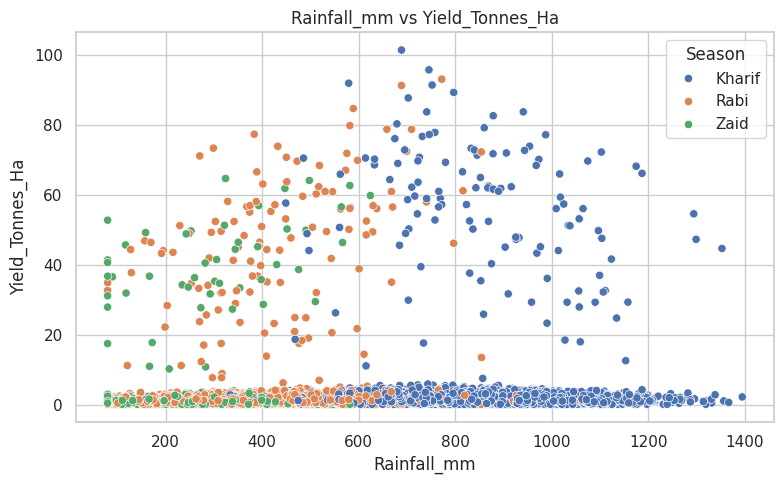

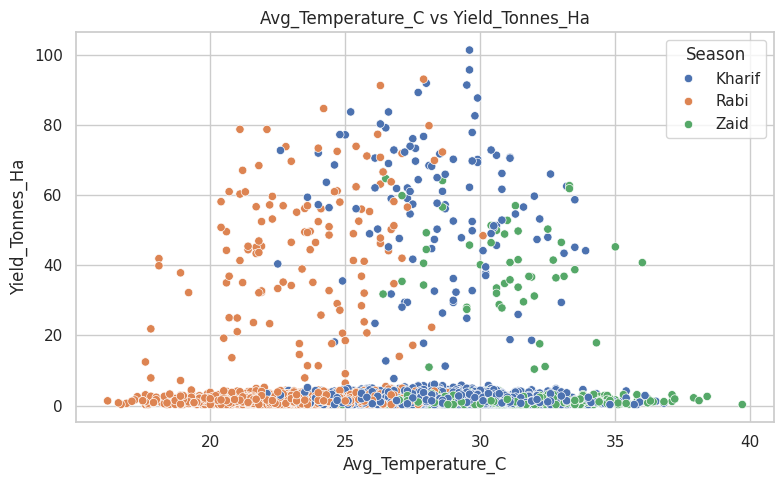

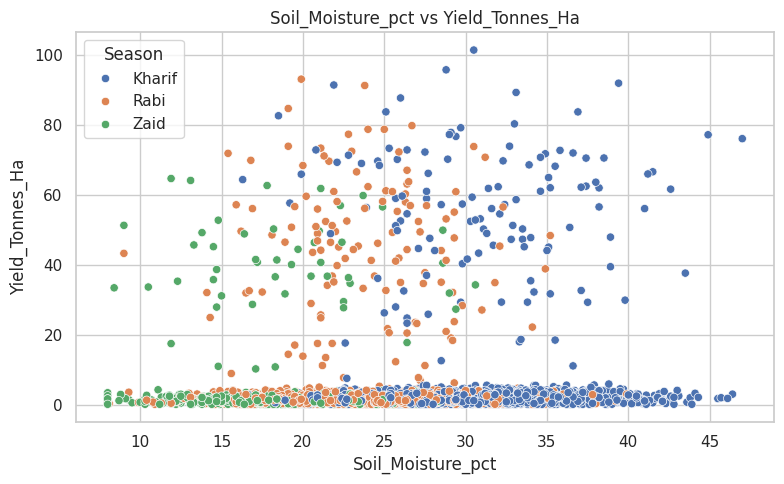

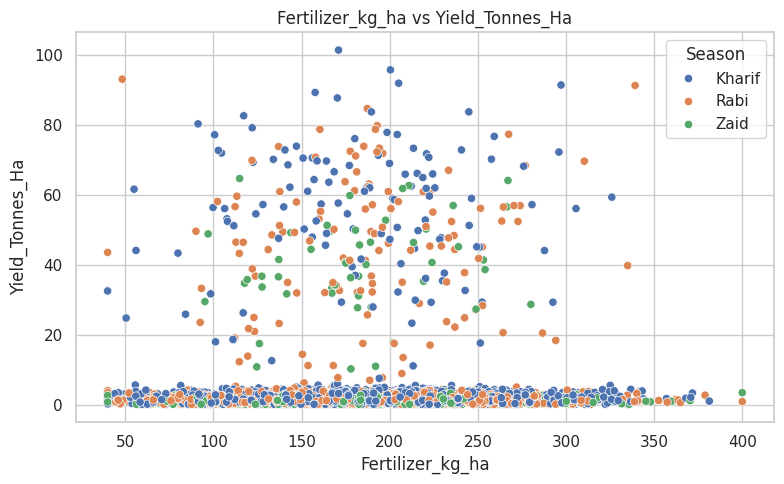

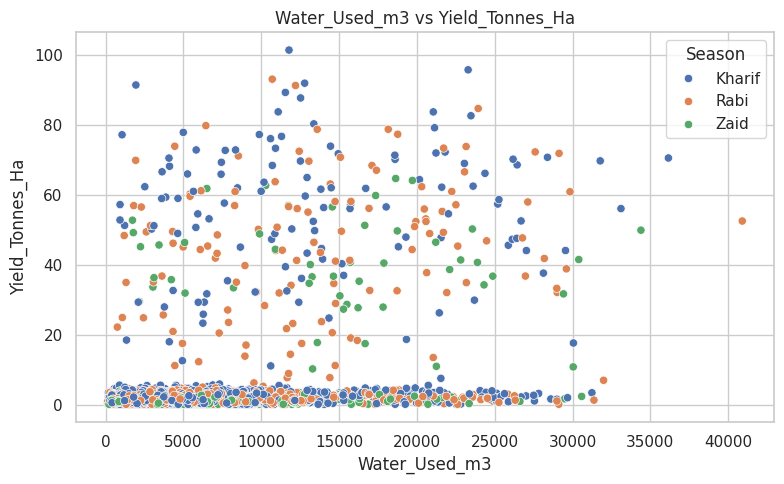

In [28]:
relationship_pairs = [
    ("Rainfall_mm", "Yield_Tonnes_Ha"),
    ("Avg_Temperature_C", "Yield_Tonnes_Ha"),
    ("Soil_Moisture_pct", "Yield_Tonnes_Ha"),
    ("Fertilizer_kg_ha", "Yield_Tonnes_Ha"),
    ("Water_Used_m3", "Yield_Tonnes_Ha")
]

for x, y in relationship_pairs:
    if {x, y}.issubset(df.columns):
        plt.figure(figsize=(8, 5))
        sns.scatterplot(
            data=df,
            x=x,
            y=y,
            hue="Season" if "Season" in df.columns else None
        )
        plt.title(f"{x} vs {y}")
        plt.tight_layout()
        plt.show()

## 17. Outlier Analysis

Outliers are flagged for investigation using the IQR method. They are not automatically deleted,
because extreme agricultural conditions may be meaningful.

In [29]:
def iqr_outlier_summary(data, columns):
    rows = []
    for col in columns:
        s = data[col].dropna()
        if s.empty:
            continue
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        count = ((s < lower) | (s > upper)).sum()
        rows.append({
            "Column": col,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "Lower_Bound": lower,
            "Upper_Bound": upper,
            "Outlier_Count": int(count),
            "Outlier_Percent": round(count / len(s) * 100, 2)
        })
    return pd.DataFrame(rows).sort_values("Outlier_Count", ascending=False)

outlier_cols = [
    c for c in [
        "Rainfall_mm", "Avg_Temperature_C", "Humidity_pct",
        "Yield_Tonnes_Ha", "Production_Tonnes",
        "Total_Cost_INR", "Revenue_INR", "Profit_INR",
        "Water_Used_m3", "Disease_Pest_Risk_pct"
    ] if c in df.columns
]

outlier_summary = iqr_outlier_summary(df, outlier_cols)
display(outlier_summary)

,Column,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percent
7,Profit_INR,"-148,731.750","216,187.750","364,919.500","-696,111.000","763,567.000",404,10.100
4,Production_Tonnes,5.020,24.355,19.335,-23.983,53.358,333,8.330
3,Yield_Tonnes_Ha,1.050,2.830,1.780,-1.620,5.500,302,7.550
8,Water_Used_m3,"2,268.750","7,829.750","5,561.000","-6,072.750","16,171.250",276,6.900
6,Revenue_INR,"207,517.250","836,874.750","629,357.500","-736,519.000","1,780,911.000",240,6.000
9,Disease_Pest_Risk_pct,37.300,54.900,17.600,10.900,81.300,10,0.250
2,Humidity_pct,54.775,71.900,17.125,29.087,97.588,6,0.150
1,Avg_Temperature_C,23.900,29.600,5.700,15.350,38.150,2,0.050
0,Rainfall_mm,371.575,831.975,460.400,-319.025,"1,522.575",0,0.000
5,Total_Cost_INR,"274,577.500","761,996.500","487,419.000","-456,551.000","1,493,125.000",0,0.000


## 18. Statistical Comparison Across Seasons

A one-way ANOVA is used when at least two seasons are available. It checks whether group means
differ statistically; it does not prove causation.

In [30]:
try:
    from scipy.stats import f_oneway

    if {"Season", "Yield_Tonnes_Ha"}.issubset(df.columns):
        groups = [
            g["Yield_Tonnes_Ha"].dropna().values
            for _, g in df.groupby("Season")
        ]
        groups = [g for g in groups if len(g) > 1]

        if len(groups) >= 2:
            statistic, p_value = f_oneway(*groups)
            print(f"ANOVA F-statistic: {statistic:.4f}")
            print(f"ANOVA p-value   : {p_value:.6f}")

            if p_value < 0.05:
                print("Interpretation: Mean yield differs significantly across at least some seasons (p < 0.05).")
            else:
                print("Interpretation: The available evidence does not show a statistically significant mean-yield difference across seasons (p >= 0.05).")
except ImportError:
    print("SciPy is not installed. Run: %pip install scipy")

ANOVA F-statistic: 1.5439
ANOVA p-value   : 0.213678
Interpretation: The available evidence does not show a statistically significant mean-yield difference across seasons (p >= 0.05).


## 19. Best-Performing Season and Crop

These rankings are calculated from the actual dataset after execution.

In [31]:
def ranked_group(data, group_col, value_col, agg="mean", ascending=False):
    if {group_col, value_col}.issubset(data.columns):
        return (
            data.groupby(group_col)[value_col]
                .agg(agg)
                .sort_values(ascending=ascending)
        )
    return pd.Series(dtype=float)

best_season_yield = ranked_group(df, "Season", "Yield_Tonnes_Ha")
best_crop_yield = ranked_group(df, "Crop", "Yield_Tonnes_Ha")
best_state_yield = ranked_group(df, "State", "Yield_Tonnes_Ha")

print("Season ranking by average yield:")
display(best_season_yield.to_frame("Average Yield"))

print("Crop ranking by average yield:")
display(best_crop_yield.head(10).to_frame("Average Yield"))

print("State ranking by average yield:")
display(best_state_yield.head(10).to_frame("Average Yield"))

Season ranking by average yield:


,Average Yield
Season,
Kharif,5.629
Rabi,5.039
Zaid,4.641


Crop ranking by average yield:


,Average Yield
Crop,
Sugarcane,46.642
Maize,2.710
Rice,2.431
Wheat,2.108
Chilli,1.543
Groundnut,1.323
Cotton,1.230
Pulses,0.922


State ranking by average yield:


,Average Yield
State,
Punjab,6.121
Karnataka,5.685
Gujarat,5.659
Telangana,5.044
Maharashtra,5.017
Madhya Pradesh,4.990
Tamil Nadu,4.875
Andhra Pradesh,4.629


## 20. Automatic Key Findings

This section converts computed results into concise evidence-based statements. It does not
hard-code which season or crop is best.

In [32]:
findings = []

if len(best_season_yield) > 0:
    best = best_season_yield.index[0]
    worst = best_season_yield.index[-1]
    findings.append(
        f"Highest average yield season: {best}; lowest average yield season: {worst}."
    )

if len(best_crop_yield) > 0:
    findings.append(
        f"Highest average-yield crop in the dataset: {best_crop_yield.index[0]}."
    )

if len(best_state_yield) > 0:
    findings.append(
        f"Highest average-yield state in the dataset: {best_state_yield.index[0]}."
    )

if {"Season", "Profit_INR"}.issubset(df.columns):
    profit_season = df.groupby("Season")["Profit_INR"].mean().sort_values(ascending=False)
    findings.append(
        f"Highest average profit season: {profit_season.index[0]}."
    )

if {"Season", "Water_Used_m3"}.issubset(df.columns):
    water_season = df.groupby("Season")["Water_Used_m3"].mean().sort_values()
    findings.append(
        f"Lowest average water-use season: {water_season.index[0]}."
    )

print("KEY FINDINGS")
for item in findings:
    print("•", item)

KEY FINDINGS
• Highest average yield season: Kharif; lowest average yield season: Zaid.
• Highest average-yield crop in the dataset: Sugarcane.
• Highest average-yield state in the dataset: Punjab.
• Highest average profit season: Kharif.
• Lowest average water-use season: Rabi.


## 21. Evidence-Based Recommendations

Recommendations should be based on the executed results rather than assumptions.

In [33]:
recommendations = []

if len(best_season_yield) > 0:
    recommendations.append(
        f"Consider {best_season_yield.index[0]} as a benchmark for higher-yield performance, "
        "while checking whether its environmental and resource conditions can be replicated."
    )

if {"Season", "Water_Used_m3", "Yield_Tonnes_Ha"}.issubset(df.columns):
    tmp = df.groupby("Season")[["Water_Used_m3", "Yield_Tonnes_Ha"]].mean()
    efficiency_proxy = (
        tmp["Yield_Tonnes_Ha"] /
        tmp["Water_Used_m3"].replace(0, np.nan)
    ).sort_values(ascending=False)

    if not efficiency_proxy.empty:
        recommendations.append(
            f"Investigate {efficiency_proxy.index[0]} practices as a potential reference "
            "for better yield per unit of water."
        )

if {"Season", "Profit_INR"}.issubset(df.columns):
    profit = df.groupby("Season")["Profit_INR"].mean().sort_values(ascending=False)
    recommendations.append(
        f"Compare costs and market outcomes in {profit.index[0]} before making crop-planning decisions."
    )

recommendations.append(
    "Use crop- and region-level analysis instead of applying one seasonal strategy to every farm."
)
recommendations.append(
    "Validate flagged outliers with farm records before removing them from future analyses."
)

for i, rec in enumerate(recommendations, 1):
    print(f"{i}. {rec}")

1. Consider Kharif as a benchmark for higher-yield performance, while checking whether its environmental and resource conditions can be replicated.
2. Investigate Kharif practices as a potential reference for better yield per unit of water.
3. Compare costs and market outcomes in Kharif before making crop-planning decisions.
4. Use crop- and region-level analysis instead of applying one seasonal strategy to every farm.
5. Validate flagged outliers with farm records before removing them from future analyses.


## 22. Final Conclusion

After running the notebook, the final conclusion should summarize:
- the strongest seasonal patterns,
- important differences in agricultural performance,
- relationships supported by the data,
- operational and economic implications,
- limitations of the available dataset,
- and practical seasonal planning recommendations.

In [34]:
print("=" * 80)
print("FINAL PROJECT SUMMARY")
print("=" * 80)
print(f"Records analyzed : {len(df):,}")
print(f"Columns analyzed : {df.shape[1]:,}")
print(f"Seasons         : {df['Season'].nunique() if 'Season' in df.columns else 'N/A'}")
print(f"Crops           : {df['Crop'].nunique() if 'Crop' in df.columns else 'N/A'}")
print(f"States          : {df['State'].nunique() if 'State' in df.columns else 'N/A'}")
print(f"Missing values  : {int(df.isna().sum().sum()):,}")
print(f"Duplicate rows  : {int(df.duplicated().sum()):,}")
print("=" * 80)

if findings:
    print("\nKey findings:")
    for item in findings:
        print("-", item)

FINAL PROJECT SUMMARY
Records analyzed : 4,000
Columns analyzed : 32
Seasons         : 3
Crops           : 8
States          : 8
Missing values  : 0
Duplicate rows  : 0

Key findings:
- Highest average yield season: Kharif; lowest average yield season: Zaid.
- Highest average-yield crop in the dataset: Sugarcane.
- Highest average-yield state in the dataset: Punjab.
- Highest average profit season: Kharif.
- Lowest average water-use season: Rabi.


## 23. Export Cleaned Dataset and Summary Tables

In [35]:
OUTPUT_DIR = "project_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

df.to_csv(
    os.path.join(OUTPUT_DIR, "C_PUSHPALATHA_seasonal_agriculture_cleaned.csv"),
    index=False
)

if "season_summary" in globals():
    season_summary.to_csv(
        os.path.join(OUTPUT_DIR, "seasonal_performance_summary.csv")
    )

if "outlier_summary" in globals():
    outlier_summary.to_csv(
        os.path.join(OUTPUT_DIR, "outlier_summary.csv"),
        index=False
    )

print("Output files created in:", os.path.abspath(OUTPUT_DIR))

Output files created in: /content/project_outputs


## 24. Submission Checklist

### Notebook
- Dataset loading
- Dataset understanding
- Data cleaning
- Missing-value and duplicate checks
- Seasonal comparison
- Crop analysis
- Regional analysis
- Environmental analysis
- Resource usage analysis
- Economic analysis
- Correlation analysis
- Outlier analysis
- Statistical comparison
- Findings
- Recommendations
- Exported cleaned dataset

### PPT
Use the supplied VOIS PPT template and fill:
1. Student Name: **C PUSHPALATHA**
2. College: **Justice Basheer Ahmed Sayeed College for Women**
3. AICTE ID: **STU696132c929d891767977673**
4. Problem Statement
5. Project Description
6. End Users
7. Technology Used
8. Results with screenshots from this notebook
9. Future Scope
10. Your GitHub repository link
11. Course completion certificate

### GitHub
Recommended files:
- `C_PUSHPALATHA_Seasonal_Agriculture_Performance_Analysis.ipynb`
- `seasonal_agriculture_performance_dataset.csv`
- `project_outputs/`
- `README.md`
- final PPT

## 25. Future Scope

- Extend the dataset with additional years and regions.
- Add verified weather and market-price sources.
- Build an interactive Power BI dashboard.
- Add predictive modelling only if required by a future project phase.
- Develop crop-season recommendation logic based on validated historical evidence.
- Integrate live agricultural or weather data where an approved source is available.

## 26. Student Information

**Name:** C PUSHPALATHA  
**AICTE ID:** STU696132c929d891767977673  
**College:** Justice Basheer Ahmed Sayeed College for Women  
**GitHub:** https://github.com/cpushpalatha9